# Ant Mutilated – Checkpoint Replay

Loads a policy checkpoint produced by `train_ant_mutilated_kandel.py` and
evaluates it across all morphological variants (none, FR, FL, RL, RR).

**Cells to fill in:** only the *Configuration* cell.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["MUJOCO_GL"] = "egl"

import json
from pathlib import Path
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import mediapy as media
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mujoco import mjx
from mujoco_playground._src.dm_control_suite import common
from omegaconf import OmegaConf
from orbax.checkpoint import StandardCheckpointer

import crawler_playground  # registers environments
from crawler_playground.envs.ant.ant import Run as AntRun, default_config
from crawler_playground.envs.ant.randomize import (
    VALID_VARIANTS,
)
from kandel.model import networks
from kandel.utility.checkpoint_manager import (
    EPISODE_NAME,
    INDIVIDUAL_NAME,
    ENSEMBLE_NAME,
)
from kandel.utility.running_statistics import init_state, normalize, update

print("JAX devices:", jax.devices())

Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Module` will soon be removed from the public API. Use `warp.Module` instead.
Warp DeprecationWarning: The symbol `warp.context.get_module` will soon be removed from the public API. Use `warp.get_module` instead.
Warp DeprecationWarning: The namespace `warp.math` will soon be removed from the public API. It can still be accessed from `warp._src.math` but might be changed or removed without notice.
JAX devices: [CpuDevice(id=0)]


## Configuration

In [2]:
# ── Fill in ────────────────────────────────────────────────────────────────────
CHECKPOINT_DIR = "/home/alexanderdittrich/Downloads/tamara/260319162623-ant-mutilated-mlp-hebbian-openai-es-145"
CHECKPOINT_STEP = 999  # generation number saved by CheckpointManager
POLICY_ID = 0  # integer → elite policy_0, policy_1 …; None → ensemble mean

EVAL_VARIANTS = ["none", "FR", "FL", "RL", "RR"]  # subset or all
NUM_SEEDS = 10  # rollouts per variant
RENDER_VARIANT = "none"  # which variant to render (set to None to skip)
# ──────────────────────────────────────────────────────────────────────────────

## Load checkpoint

In [3]:
checkpoint_directory = Path(CHECKPOINT_DIR)
cfg = OmegaConf.load(checkpoint_directory / "metadata.yaml")

# ── Norm state ─────────────────────────────────────────────────────────────────
meta_path = (
    checkpoint_directory
    / f"{EPISODE_NAME}_{CHECKPOINT_STEP}"
    / "checkpoint_metadata.json"
)
with open(meta_path) as f:
    meta = json.load(f)

norm_data = meta["norm_state"]
dummy_obs = jnp.zeros((cfg.observation_dim,))
norm_state = init_state(dummy_obs).replace(
    mean=jnp.array(norm_data["mean"]),
    std=jnp.array(norm_data["std"]),
    summed_variance=jnp.array(norm_data["summed_variance"]),
    count=0,
)

# ── Policy ─────────────────────────────────────────────────────────────────────
policy = networks[cfg.policy_id](
    input_dim=cfg.observation_dim,
    output_dim=cfg.action_dim,
    **cfg.policy,
)
dummy_params = policy.initialize(jax.random.key(0))

policy_subdir = (
    f"{INDIVIDUAL_NAME}_{POLICY_ID}"
    if isinstance(POLICY_ID, int)
    else ENSEMBLE_NAME
)
policy_path = (
    checkpoint_directory / f"{EPISODE_NAME}_{CHECKPOINT_STEP}" / policy_subdir
)
policy_params_init = StandardCheckpointer().restore(policy_path, dummy_params)

# ── Timing ─────────────────────────────────────────────────────────────────────
sim_interval = cfg.simulation_interval
update_interval = cfg.update_interval
total_time = cfg.rollout_length * sim_interval
total_steps = int(total_time / min(sim_interval, update_interval))

relative_sim_steps = int(total_steps / cfg.rollout_length)
relative_update_steps = int(total_steps / int(total_time / update_interval))

print(f"Policy:          {cfg.policy_id} ({policy_subdir})")
print(f"Strategy:        {cfg.strategy_id}")
print(f"Train variants:  {list(cfg.train_variants)}")
print(f"Test variants:   {list(cfg.test_variants)}")
print(f"Rollout length:  {cfg.rollout_length} steps  ({total_time:.2f} s)")
print(
    f"Sim / update Δt: {sim_interval * 1000:.0f} ms / {update_interval * 1000:.0f} ms"
)

Policy:          mlp-hebbian (policy_0)
Strategy:        openai-es
Train variants:  ['none', 'FR', 'FL']
Test variants:   ['RR', 'RL']
Rollout length:  1000 steps  (50.00 s)
Sim / update Δt: 50 ms / 50 ms


## Environment factory

In [4]:
_ANT_XML_DIR = (
    Path(crawler_playground.__file__).parent / "envs" / "ant" / "xmls"
)

# Apply the same env overrides used during training (episode_length, ctrl_dt, etc.)
_env_overrides = (
    OmegaConf.to_container(cfg.env, resolve=True) if "env" in cfg else {}
)


def make_variant_env(variant: str) -> AntRun:
    """Return an AntRun configured identically to training for *variant*.

    Applies cfg.env overrides from the checkpoint (episode_length, ctrl_dt, …)
    so the environment matches training exactly.  For damaged variants the
    matching ant_mutilated_<V>.xml is loaded so visual geometry matches physics.
    """
    assert variant in VALID_VARIANTS, f"Unknown variant '{variant}'"
    env = AntRun(config=default_config(), config_overrides=_env_overrides)
    if variant != "none":
        xml_path = _ANT_XML_DIR / f"ant_mutilated_{variant}.xml"
        mj_model = mujoco.MjModel.from_xml_string(
            xml_path.read_text(), common.get_assets()
        )
        mj_model.opt.timestep = env.sim_dt
        env._mj_model = mj_model
        env._mjx_model = mjx.put_model(mj_model)
    return env


# JIT-compile once and reuse across seeds within a variant.
obs_normalize_fn = jax.jit(normalize)
policy_forward_fn = jax.jit(policy.forward)
policy_update_fn = jax.jit(policy.update)
policy_reset_fn = jax.jit(policy.reset)

## Rollout helper

In [5]:
def make_rollout_fns(env):
    """JIT-compile env functions once per variant; return (single_rollout, batch_rollout).

    Uses a frozen norm_state (from the checkpoint) for observation normalisation.
    This is the correct eval behaviour: the checkpoint mean/std were computed over
    millions of training observations and are well-calibrated.  Updating online
    would be harmful here because the checkpoint is loaded with count=0, so the
    first Welford update would reset the mean to a single observation and collapse
    std to 1e-6 (its clip floor), exploding normalised observations.

    Matches the training rollout in train_ant_mutilated_kandel.py in all other
    respects: Hebbian update fires every `relative_update_steps` steps via
    lax.cond; all seeds run in parallel via vmap + lax.scan.
    """
    env_reset_j = jax.jit(env.reset)
    env_step_j = jax.jit(env.step)

    def rollout(seed: int):
        key = jax.random.key(seed)
        rng_env, rng_policy = jax.random.split(key)
        pp = policy_reset_fn(policy_params_init, rng_policy)
        es = env_reset_j(rng_env)

        def scan_fn(carry, t):
            pp, es = carry
            obs = obs_normalize_fn(
                es.obs, norm_state
            )  # frozen checkpoint stats
            pp, actions = policy_forward_fn(pp, obs)
            actions = jnp.clip(
                actions, cfg.action_clip_min, cfg.action_clip_max
            )
            es = env_step_j(es, actions)
            pp = jax.lax.cond(
                t % relative_update_steps == 0,
                policy_update_fn,
                lambda p: p,
                pp,
            )
            return (pp, es), (es, actions, es.reward)

        _, (state_hist, action_hist, rewards) = jax.lax.scan(
            scan_fn,
            (pp, es),
            jnp.arange(cfg.rollout_length),
        )
        return state_hist, action_hist, jnp.sum(rewards)

    # vmap over seeds, compiled once per variant
    batch_rollout = jax.jit(jax.vmap(rollout))
    return rollout, batch_rollout


def state_at(state_hist, t):
    """Slice a scan-output state pytree at a single timestep t."""
    return jax.tree_util.tree_map(lambda x: x[t], state_hist)

## Evaluate across all variants

In [6]:
results = {}
train_variants = list(cfg.train_variants)
seeds = jnp.arange(NUM_SEEDS)

for variant in EVAL_VARIANTS:
    env = make_variant_env(variant)
    rollout_fn, batch_rollout = make_rollout_fns(env)

    # All seeds run in parallel via vmap; compiled once per variant.
    # state_hists / action_hists are pytrees with shape [num_seeds, rollout_length, ...]
    state_hists, action_hists, total_rewards = batch_rollout(seeds)
    variant_rewards = np.asarray(total_rewards)

    results[variant] = {
        "env": env,
        "rollout_fn": rollout_fn,
        "rewards": variant_rewards,
        "state_hists": state_hists,  # pytree [seeds, T, ...]
        "action_hists": action_hists,  # [seeds, T, action_dim]
    }
    split = "train" if variant in train_variants else "test "
    print(
        f"[{split}] {variant:4s}  "
        f"reward = {np.mean(variant_rewards):7.1f} ± {np.std(variant_rewards):.1f}  "
        f"(min {np.min(variant_rewards):.1f}, max {np.max(variant_rewards):.1f})"
    )

[train] none  reward =  3018.2 ± 126.4  (min 2789.1, max 3213.7)
[train] FR    reward =  3102.6 ± 343.8  (min 2122.5, max 3364.4)
[train] FL    reward =  2103.1 ± 18.9  (min 2080.2, max 2141.4)
[test ] RL    reward =  1336.5 ± 38.9  (min 1279.2, max 1404.6)
[test ] RR    reward =   590.2 ± 618.3  (min -187.2, max 1563.5)


## Reward comparison

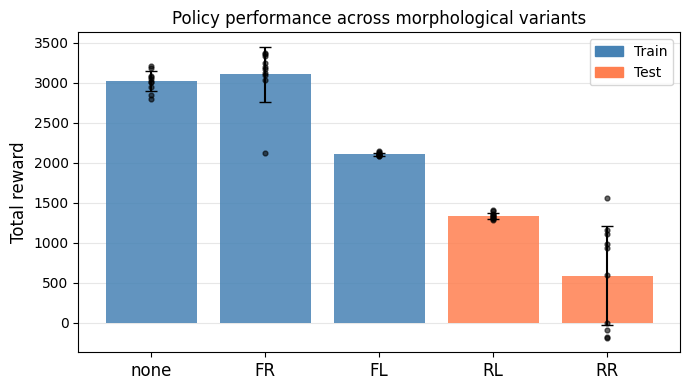

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, variant in enumerate(EVAL_VARIANTS):
    rewards = results[variant]["rewards"]
    is_train = variant in train_variants
    color = "steelblue" if is_train else "coral"
    ax.bar(i, np.mean(rewards), color=color, alpha=0.85, zorder=2)
    ax.errorbar(
        i,
        np.mean(rewards),
        yerr=np.std(rewards),
        fmt="none",
        color="black",
        capsize=4,
        linewidth=1.5,
        zorder=3,
    )
    for r in rewards:
        ax.scatter(i, r, color="black", s=12, zorder=4, alpha=0.6)

ax.set_xticks(range(len(EVAL_VARIANTS)))
ax.set_xticklabels(EVAL_VARIANTS, fontsize=12)
ax.set_ylabel("Total reward", fontsize=12)
ax.set_title("Policy performance across morphological variants")
ax.grid(axis="y", alpha=0.3)
ax.legend(
    handles=[
        mpatches.Patch(color="steelblue", label="Train"),
        mpatches.Patch(color="coral", label="Test"),
    ]
)
plt.tight_layout()
plt.show()

## Trajectories (top-down)

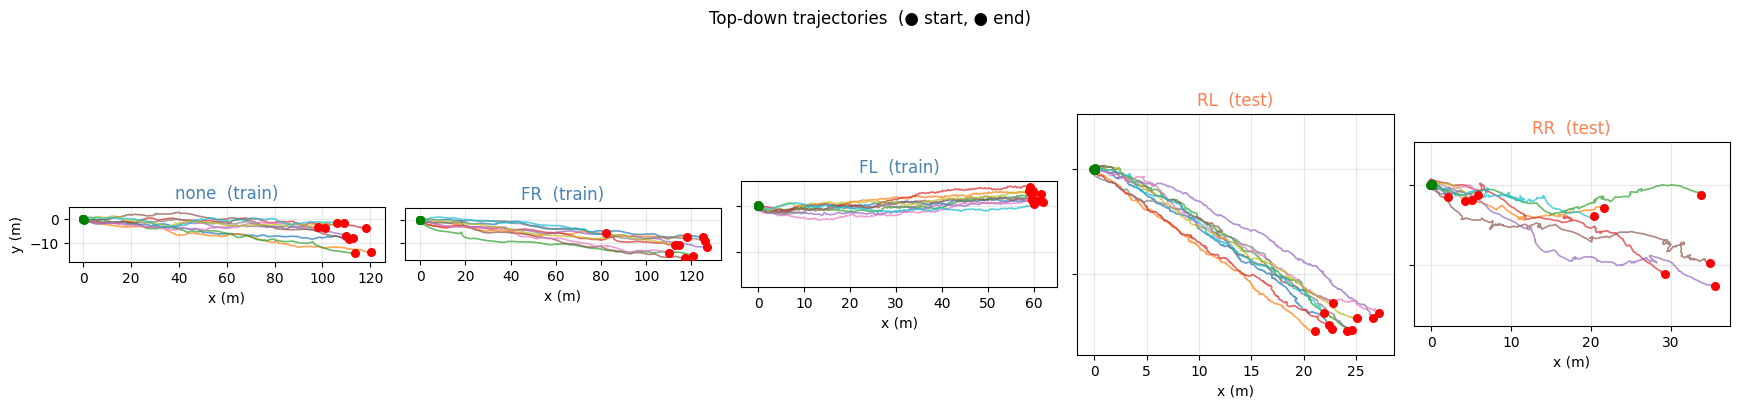

In [8]:
fig, axs = plt.subplots(
    1,
    len(EVAL_VARIANTS),
    figsize=(3.5 * len(EVAL_VARIANTS), 4),
    sharey=True,
)
if len(EVAL_VARIANTS) == 1:
    axs = [axs]

for ax, variant in zip(axs, EVAL_VARIANTS):
    # state_hists.data.xpos: [num_seeds, rollout_length, nbody, 3]
    xpos_all = np.asarray(
        results[variant]["state_hists"].data.xpos[:, :, 1, :]
    )  # [seeds, T, 3]
    for seed_idx in range(NUM_SEEDS):
        xpos = xpos_all[seed_idx]  # [T, 3]
        ax.plot(
            xpos[:, 0],
            xpos[:, 1],
            alpha=0.7,
            linewidth=1.2,
            label=f"seed {seed_idx}",
        )
        ax.scatter(xpos[0, 0], xpos[0, 1], s=30, color="green", zorder=5)
        ax.scatter(xpos[-1, 0], xpos[-1, 1], s=30, color="red", zorder=5)

    is_train = variant in train_variants
    title_color = "steelblue" if is_train else "coral"
    ax.set_title(
        f"{variant}  ({'train' if is_train else 'test'})", color=title_color
    )
    ax.set_xlabel("x (m)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

axs[0].set_ylabel("y (m)")
plt.suptitle("Top-down trajectories  (● start, ● end)", y=1.02)
plt.tight_layout()
plt.show()

## Forward velocity over time

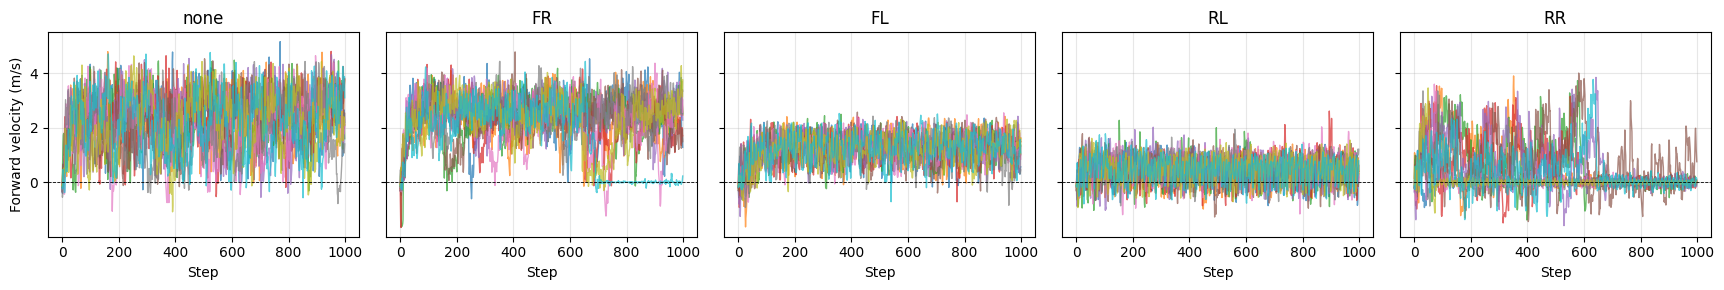

In [9]:
fig, axs = plt.subplots(
    1,
    len(EVAL_VARIANTS),
    figsize=(3.5 * len(EVAL_VARIANTS), 3),
    sharey=True,
)
if len(EVAL_VARIANTS) == 1:
    axs = [axs]

for ax, variant in zip(axs, EVAL_VARIANTS):
    # state_hists.data.xpos: [num_seeds, rollout_length, nbody, 3]
    xpos_all = np.asarray(
        results[variant]["state_hists"].data.xpos[:, :, 1, 0]
    )  # [seeds, T]
    for seed_idx in range(NUM_SEEDS):
        velocity = np.diff(xpos_all[seed_idx]) / sim_interval
        ax.plot(velocity, alpha=0.7, linewidth=1)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(variant)
    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)

axs[0].set_ylabel("Forward velocity (m/s)")
plt.tight_layout()
plt.show()

## Video rendering

Set `RENDER_VARIANT` in the *Configuration* cell to choose which variant to render,
or loop over all of them.

In [10]:
RENDER_VARIANT = None
SEED = 5

for variant in EVAL_VARIANTS:
    print(results[variant]["rewards"], results[variant]["rewards"][SEED])

[3039.648  3213.731  3079.6108 3184.1953 3013.8694 3068.3972 2848.148
 2789.0554 3001.8308 2943.9954] 3068.3972
[3335.277  3192.8552 3240.6804 3088.904  3364.3962 3168.8774 3036.1692
 3351.977  3124.454  2122.456 ] 3168.8774
[2095.2246 2092.6677 2130.9697 2086.9326 2141.3945 2092.8032 2116.4507
 2094.0503 2080.224  2100.196 ] 2092.8032
[1317.2081 1279.2323 1340.5698 1306.9434 1392.7439 1315.1062 1404.5862
 1350.3997 1360.9968 1296.9305] 1315.1062
[-187.17073    601.7885    1111.9529     980.9277    1162.8933
 1563.487       -2.2947435  -86.51631   -178.17773    934.8184   ] 1563.487


In [ ]:
import imageio

render_variants = EVAL_VARIANTS if RENDER_VARIANT is None else [RENDER_VARIANT]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False

for variant in render_variants:
    env = results[variant]["env"]
    reward = float(results[variant]["rewards"][SEED])

    # Re-run seed 0 as a single rollout to get a list-of-states traj for env.render.
    state_hist, _, _ = results[variant]["rollout_fn"](SEED)
    render_every = 1
    fps = (1.0 / env.dt) / render_every
    T = jax.tree_util.tree_leaves(state_hist)[0].shape[0]
    traj = [state_at(state_hist, t) for t in range(0, T, render_every)]

    frames = env.render(
        traj,
        height=480,
        width=640,
        camera=0,
        scene_option=scene_option,
    )
    print(
        f"Variant: {variant}  |  reward = {reward:.1f}  |  {len(frames)} frames @ {fps:.0f} fps"
    )
    media.show_video(frames, fps=fps)
    gif_path = f"ant_mutilated_{variant}_seed{SEED}.gif"
    imageio.mimsave(gif_path, frames, fps=fps)
    print(f"Saved {gif_path}")

## Hebbian weight dynamics (first seed, selected variant)

Collected 1000 snapshots  |  16 param leaves  |  3427 total dims


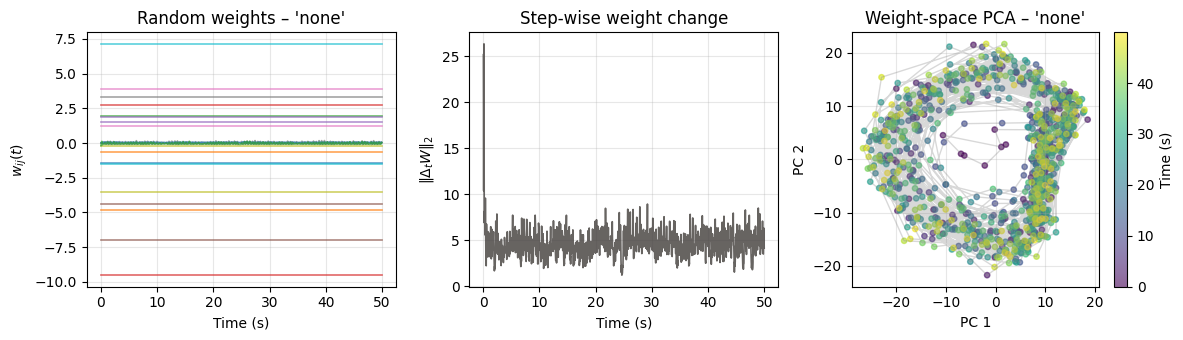

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ── Config ────────────────────────────────────────────────────────────────────
WEIGHT_VARIANT = "none"  # change as needed
WEIGHT_SEED = 5
NUM_RANDOM_WEIGHTS = 20
RANDOM_WEIGHT_SEED = 1

# ── Collect weight history via lax.scan ──────────────────────────────────────
# Re-run a single rollout that outputs policy_params at every timestep.
# Uses the same frozen norm_state as the evaluation rollout (correct for replay).
env = results[WEIGHT_VARIANT]["env"]
env_reset_j = jax.jit(env.reset)
env_step_j = jax.jit(env.step)

key = jax.random.key(WEIGHT_SEED)
rng_env, rng_policy = jax.random.split(key)
pp = policy_reset_fn(policy_params_init, rng_policy)
es = env_reset_j(rng_env)


def scan_fn_w(carry, t):
    pp, es = carry
    obs = obs_normalize_fn(es.obs, norm_state)  # frozen checkpoint stats
    pp, actions = policy_forward_fn(pp, obs)
    actions = jnp.clip(actions, cfg.action_clip_min, cfg.action_clip_max)
    es = env_step_j(es, actions)
    pp = jax.lax.cond(
        t % relative_update_steps == 0,
        policy_update_fn,
        lambda p: p,
        pp,
    )
    return (pp, es), pp  # output policy_params at every step


(_, _), pp_hist = jax.lax.scan(
    scan_fn_w,
    (pp, es),
    jnp.arange(cfg.rollout_length),
)
# pp_hist: pytree where each leaf has shape [T, *leaf_shape]

T = cfg.rollout_length
t_axis = np.arange(T) * sim_interval

# ── Flatten to weight matrix [T, total_weights] ───────────────────────────────
leaves = jax.tree_util.tree_leaves(pp_hist)
weight_mat = np.concatenate(
    [np.asarray(leaf).reshape(T, -1) for leaf in leaves], axis=1
)
print(
    f"Collected {T} snapshots  |  {len(leaves)} param leaves  |  {weight_mat.shape[1]} total dims"
)

# ── Random weight traces ───────────────────────────────────────────────────────
rng_w = np.random.default_rng(RANDOM_WEIGHT_SEED)
idx = rng_w.choice(weight_mat.shape[1], size=NUM_RANDOM_WEIGHTS, replace=False)
random_weights = weight_mat[:, idx]  # [T, num_random]

# ── Step-wise Euclidean distance (||ΔW||₂) ────────────────────────────────────
euc_dist = np.linalg.norm(np.diff(weight_mat, axis=0), axis=1)  # [T-1]

# ── PCA 2D trajectory ─────────────────────────────────────────────────────────
scaler = StandardScaler()
pca = PCA(n_components=2)
weights_pca = pca.fit_transform(scaler.fit_transform(weight_mat))  # [T, 2]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))

axs[0].plot(t_axis, random_weights, alpha=0.7, linewidth=1.2)
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("$w_{ij}(t)$")
axs[0].set_title(f"Random weights – '{WEIGHT_VARIANT}'")
axs[0].grid(alpha=0.3)

axs[1].plot(t_axis[1:], euc_dist, color="#413D3A", alpha=0.8, linewidth=1.2)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel(r"$\|\Delta_t W\|_2$")
axs[1].set_title("Step-wise weight change")
axs[1].grid(alpha=0.3)

cmap_pca = cm.viridis
norm_c = mcolors.Normalize(vmin=t_axis[0], vmax=t_axis[-1])
axs[2].plot(
    weights_pca[:, 0], weights_pca[:, 1], color="grey", alpha=0.3, linewidth=1
)
sc = axs[2].scatter(
    weights_pca[:, 0],
    weights_pca[:, 1],
    c=t_axis,
    cmap=cmap_pca,
    norm=norm_c,
    s=15,
    alpha=0.6,
)
plt.colorbar(sc, ax=axs[2], label="Time (s)")
axs[2].set_xlabel("PC 1")
axs[2].set_ylabel("PC 2")
axs[2].set_title(f"Weight-space PCA – '{WEIGHT_VARIANT}'")
axs[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()